# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [14]:
from pathlib import Path
import sys, platform, hashlib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate,baseline_predictions,metrics,KEYS,YEARS
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__,
      '| numpy:',np.__version__,'| matplotlib:',matplotlib.__version__,'| OS:',platform.platform())
print('support module sha256:',hashlib.sha256((ROOT/'labs/lab_01/lab01_support_v1.py').read_bytes()).hexdigest())
BLUE, ORANGE, INK = '#2a78d6', '#eb6834', '#52514e'   # fixed colours for all plots

DATA MODE: snapshot | Python: 3.14.7 | pandas: 3.0.6 | numpy: 2.5.3 | matplotlib: 3.11.2 | OS: Linux-7.2.6-1-cachyos-x86_64-with-glibc2.44
support module sha256: 6c14fcffec5ac47c30e227857d34ae48ed87d5c5cb1457cd3f31e47d2831f9fe


**Prediction moment.** We predict after qualifying for a Grand Prix has finished and before the race starts. The only predictor is `qualifying_position` from the qualifying table, because that is what exists at that moment. Everything in the results table is post-qualifying or post-race information: `position`, `position_text`, `status`, `points`, `laps`, and also `grid`, which includes penalties and pit-lane starts applied after qualifying. We use those columns to build the label or to audit and explore the training data, never as predictors.

**Unit.** One row is one driver in one Grand Prix, identified by `season + round + driver_id`.

**Population.** Every driver/race record in the supplied results snapshot for the seasons of each role. That includes retirements, disqualifications, non-finishers and entries with no qualifying record. It is a retrospective population: it contains the records the source has today, which is not a verified list of who was entered before each race. Drivers who entered but did not start may be missing, and old records may include later corrections such as post-race penalties or disqualifications. So we are not reconstructing exactly what was known at the time.

**Target.** `target_top10 = 1` when the source's numeric final `position` is between 1 and 10, otherwise 0. This is the final classification, which is not the same thing as finishing the race. The source gives every entry a numeric position, retirements included (they are ordered by distance covered), so a retired driver could be classified in the top ten in a race with many retirements, and a car that finished can end up outside it. The target is also different from "scored points", since sprint and fastest-lap points don't line up with it, and it says nothing about constructors. Sprint races are excluded.

In [15]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

### 1.1 Extra audit: keys, duplicates, unmatched records, missingness, coverage

In [22]:
audit={}
for name,df in [('qualifying',q_train),('results',r_train)]:
    audit[name]={'rows':len(df),'null_keys':int(df[KEYS].isna().any(axis=1).sum()),
                 'duplicate_keys':int(df.duplicated(KEYS).sum()),
                 'seasons':sorted(df.season.unique().tolist()),'races':df[['season','round']].drop_duplicates().shape[0]}
display(pd.DataFrame(audit).T)

# Records present in qualifying but absent from results (they would be silently lost by a results-first left join)
anti=q_train.merge(r_train[KEYS],on=KEYS,how='left',indicator=True)
print('qualifying-only records:',int((anti._merge=='left_only').sum()))
print('results rows without qualifying (left_only):',int((train.qualifying_match=='left_only').sum()))

# Coverage: races per season, drivers per race, qualifying positions valid within race
cov=train.groupby('season').agg(races=('round','nunique'),rows=('driver_id','size'))
cov['drivers_per_race']=train.groupby(['season','round']).size().groupby('season').agg(lambda s:f'{s.min()}–{s.max()}')
cov['target_rate']=train.groupby('season').target_top10.mean()
display(cov)
qpr=q_train.groupby(['season','round']).qualifying_position.agg(['min','max','nunique','size'])
print('qualifying positions unique within every race:',bool((qpr['nunique']==qpr['size']).all()),
      '| min always 1:',bool((qpr['min']==1).all()))

,rows,null_keys,duplicate_keys,seasons,races
qualifying,1197,0,0,"[2019, 2020, 2021]",60
results,1200,0,0,"[2019, 2020, 2021]",60


qualifying-only records: 0
results rows without qualifying (left_only): 3


,races,rows,drivers_per_race,target_rate
season,,,,
2019,21,420,20–20,0.5
2020,17,340,20–20,0.5
2021,22,440,20–20,0.5


qualifying positions unique within every race: True | min always 1: True


In [23]:
# Missingness by column in the joined table (q1/q2/q3 are times from the knockout format, not used as predictors)
display(train.isna().sum().to_frame('missing').query('missing>0').T)
print('Results rows with missing qualifying position:')
display(train.loc[train.qualifying_position.isna(),['season','round','race_name','driver_id','constructor_id','grid','position','status','target_top10']])

,qualifying_position
missing,3


Results rows with missing qualifying position:


,season,round,race_name,driver_id,constructor_id,grid,position,status,target_top10
49,2019,3,Chinese Grand Prix,albon,toro_rosso,0,10,+1 Lap,1
54,2019,3,Chinese Grand Prix,giovinazzi,alfa,19,15,+1 Lap,0
857,2021,5,Monaco Grand Prix,mick_schumacher,haas,20,18,+3 Laps,0


In [24]:
# What an inner join would do to the evaluated population
inner=r_train.merge(q_train[KEYS+['qualifying_position']],on=KEYS,how='inner')
lost=train.loc[train.qualifying_match=='left_only']
print(f'left join rows: {len(train)} | inner join rows: {len(inner)} | rows lost: {len(lost)}')
print(f'target rate left: {train.target_top10.mean():.4f} | inner: {inner.position.between(1,10).mean():.4f}')
print('targets of the rows an inner join would drop:',lost.target_top10.tolist())

left join rows: 1200 | inner join rows: 1197 | rows lost: 3
target rate left: 0.5000 | inner: 0.5004
targets of the rows an inner join would drop: [1, 0, 0]


**What the audit shows.**

Train has 1,200 results rows (420, 340 and 440 for 2019, 2020 and 2021) and 1,197 qualifying rows. Neither table has a null or duplicated `season+round+driver_id` key, and the join validated as one-to-one. No qualifying record is missing from results, so starting from results doesn't lose anything.

There are 21, 17 and 22 races, each with exactly 20 drivers. 2020 is shorter because of the COVID-reduced calendar, so it counts for less in train. Since every race has 20 numerically classified drivers, exactly 10 rows per race are positive, and the training target rate comes out at exactly 0.5000 in every season. That matters for the majority baseline in Section 5.

Three results rows (0.25%) have no qualifying record. Two are from the 2019 Chinese GP: albon, who started from the pit lane and still finished 10th (target = 1), and giovinazzi, who finished 15th. The third is mick_schumacher at the 2021 Monaco GP, 18th. The gaps in q1/q2/q3 are normal for the knockout format, since only 15 drivers reach Q2 and 10 reach Q3. Those times aren't predictors here, and `qualifying_position` is never missing when the qualifying row exists.

An inner join would drop those 3 rows and leave 1,197. One of them is a positive, so the target rate would move from 0.5000 to 0.5004 (599/1,197). The bigger problem is that the qualifying rule would then only be evaluated on drivers who have a qualifying record, which quietly removes the hardest cases (drivers who couldn't qualify) and changes the population the rule is supposed to serve. With the left join those rows stay in and the fixed fallback handles them in the open.

## 2. EDA question 1: does the top-ten rate fall steadily with qualifying position, and do the rule's errors pile up near the cut-off of 10?
Train only (2019 to 2021).

qpos,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
top10_rate,0.95,0.87,0.83,0.87,0.73,0.75,0.72,0.57,0.67,0.47,0.55,0.57,0.4,0.27,0.22,0.2,0.1,0.08,0.08,0.1
n,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.00,60.0,60.00,60.00,60.0,60.0,60.00,59.00,58.0


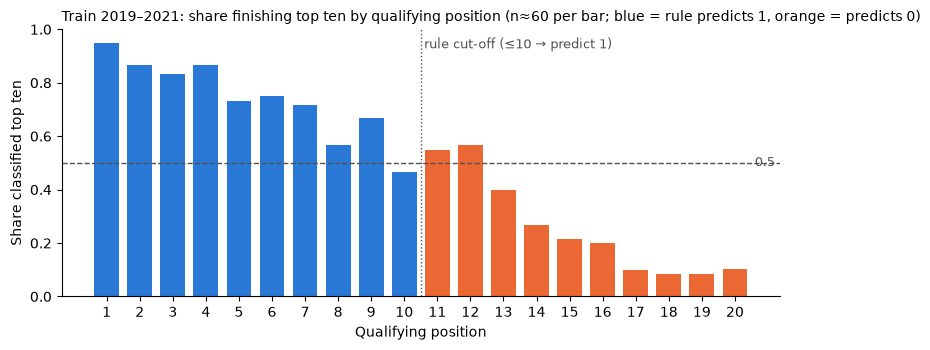

In [25]:
t=train.dropna(subset=['qualifying_position']).copy()
t['qpos']=t.qualifying_position.astype(int)
rate=t.groupby('qpos').target_top10.agg(top10_rate='mean',n='size')
display(rate.T.round(2))

fig,ax=plt.subplots(figsize=(8,3.6))
ax.bar(rate.index,rate.top10_rate,color=[BLUE if q<=10 else ORANGE for q in rate.index],width=0.75)
ax.axhline(0.5,color=INK,lw=1,ls='--'); ax.text(20.6,0.5,'0.5',va='center',color=INK,fontsize=9)
ax.axvline(10.5,color=INK,lw=1,ls=':'); ax.text(10.6,0.97,'rule cut-off (≤10 → predict 1)',color=INK,fontsize=9,va='top')
ax.set_ylim(0,1)   # full 0–1 axis on purpose: no truncated framing
ax.set_xticks(range(1,21)); ax.set_xlabel('Qualifying position'); ax.set_ylabel('Share classified top ten')
ax.set_title('Train 2019–2021: share finishing top ten by qualifying position (n≈60 per bar; blue = rule predicts 1, orange = predicts 0)',fontsize=10,loc='left')
for s in ('top','right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

,rows,errors,top10_rate,share_of_all_errors
qpos,,,,
P1-4,240,29,0.879,0.094
P5-7,180,48,0.733,0.155
P8-10,180,78,0.567,0.252
P11-13,180,91,0.506,0.294
P14-16,180,41,0.228,0.133
P17-20,237,22,0.093,0.071


P10 rate 0.47 vs P11 rate 0.55 | P8–P13 range 0.40–0.67 | approx. SE per bar ±0.065
P8–P13: 360 of 1197 rows but 169 of 309 errors


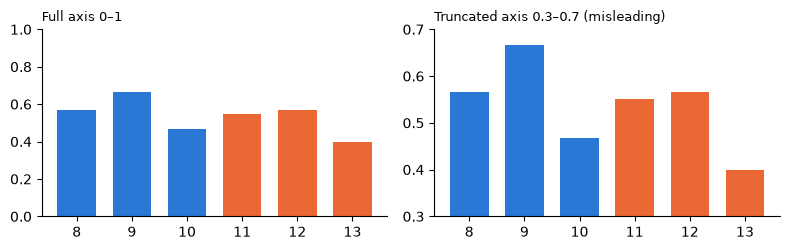

In [26]:
# Where do the qualifying-rule errors fall? (train only, fallback = 0 for the 3 missing rows)
t['pred']=t.qpos.le(10).astype(int); t['error']=t.pred!=t.target_top10
band=pd.cut(t.qpos,[0,4,7,10,13,16,20],labels=['P1-4','P5-7','P8-10','P11-13','P14-16','P17-20'])
err=t.groupby(band,observed=True).agg(rows=('error','size'),errors=('error','sum'),top10_rate=('target_top10','mean'))
err['share_of_all_errors']=err.errors/err.errors.sum()
display(err.round(3))

# Framing check: the same data plotted with a truncated axis exaggerates the P10/P11 step
se=np.sqrt(0.25/60)   # approx. standard error of a share near 0.5 with n=60
print(f'P10 rate {rate.loc[10,"top10_rate"]:.2f} vs P11 rate {rate.loc[11,"top10_rate"]:.2f} | P8–P13 range {rate.loc[8:13,"top10_rate"].min():.2f}–{rate.loc[8:13,"top10_rate"].max():.2f} | approx. SE per bar ±{se:.3f}')
print(f'P8–P13: {err.loc[["P8-10","P11-13"],"rows"].sum()} of {err.rows.sum()} rows but {err.loc[["P8-10","P11-13"],"errors"].sum()} of {err.errors.sum()} errors')
fig,axs=plt.subplots(1,2,figsize=(8,2.6))
for ax,(lo,title) in zip(axs,[(0,'Full axis 0–1'),(0.3,'Truncated axis 0.3–0.7 (misleading)')]):
    sub=rate.loc[8:13]
    ax.bar(sub.index,sub.top10_rate,color=[BLUE if q<=10 else ORANGE for q in sub.index],width=0.7)
    ax.set_ylim(lo,1 if lo==0 else 0.7); ax.set_title(title,fontsize=9,loc='left'); ax.set_xticks(sub.index)
    for s in ('top','right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Answer.** Mostly yes. The top-ten share drops from 0.95 at P1 to 0.73 at P5 and to 0.08 to 0.10 at P17 to P20 (each bar has 58 to 60 rows, one per race). Near the cut-off it is not a clean step, though. P8 to P13 all sit between 0.40 and 0.67, and the order isn't even monotonic: P10 (0.47) is below P11 (0.55) and P12 (0.57). The P8 to P13 band has 30% of the rows (360 of 1,197) but 55% of the qualifying rule's errors (169 of the 309 errors among rows with a qualifying position). P1 to P4 and P17 to P20 together account for only 16% of the errors.

**Framing check.** With about 60 races per bar, each share has a standard error of roughly ±0.065, so the 0.08 gap where P10 sits below P11 is within noise. It does not mean qualifying 11th is better than 10th. The right-hand panel shows what a truncated 0.3 to 0.7 axis does to the same bars: noise starts to look like structure. We plot rates on a full 0 to 1 axis, show n per bar, and don't read anything into single-position wiggles.

**Decision.** The rate crosses 0.5 around P10 to P12, so the fixed threshold of 10 is a reasonable reference and we leave it alone, as the brief requires. We also wouldn't try to "fix" the P10/P11 reversal, because that would be fitting noise. A prediction for someone who qualified P1 to P4 or P17 to P20 deserves much more trust than one for P8 to P13, where the rule is close to a coin flip. We expect the calibration and test errors to concentrate in that band.

## 3. EDA question 2: would evaluating only the drivers who finished make the qualifying rule look better than it is?
Train only. `status` is post-race information, so we use it here to audit the population and never as a filter or a predictor.

In [28]:
tr=train.copy()
tr['finished']=tr.status.eq('Finished')|tr.status.str.match(r'^\+\d+ Laps?$')   # 'Finished' or lapped but running
print('status groups:',tr.finished.map({True:'finished/lapped',False:'retired/DSQ/other'}).value_counts().to_dict())
display(pd.crosstab(tr.finished.map({True:'finished/lapped',False:'retired/DSQ/other'}),tr.target_top10,margins=True))

pred_tr=baseline_predictions(tr,0)   # majority=0 is derived in Section 5; used here only to reproduce the fallback
rows=[]
for label,mask in [('all rows (correct population)',pd.Series(True,index=tr.index)),('finishers only (selected)',tr.finished)]:
    m=metrics(tr.loc[mask,'target_top10'],pred_tr.loc[mask,'qualifying_top10'])
    rows.append({'population':label,'target_rate':tr.loc[mask,'target_top10'].mean(),**m})
display(pd.DataFrame(rows).set_index('population').round(3))

nf=tr[~tr.finished]
print('non-finishers who qualified top ten:',int(nf.qualifying_position.le(10).sum()),
      '→ all are false POSITIVES of the qualifying rule (predicted 1, classified outside the top ten)')
print('share of train false positives that are non-finishers:',
      round(float(((pred_tr.qualifying_top10==1)&(tr.target_top10==0)&~tr.finished).sum()/((pred_tr.qualifying_top10==1)&(tr.target_top10==0)).sum()),3))

status groups: {'finished/lapped': 1024, 'retired/DSQ/other': 176}


target_top10,0,1,All
finished,,,
finished/lapped,424,600,1024
retired/DSQ/other,176,0,176
All,600,600,1200


,target_rate,n,TN,FP,FN,TP,accuracy,balanced_accuracy
population,,,,,,,,
all rows (correct population),0.500,1200,445,155,155,445,0.742,0.742
finishers only (selected),0.586,1024,343,81,155,445,0.770,0.775


non-finishers who qualified top ten: 74 → all are false POSITIVES of the qualifying rule (predicted 1, classified outside the top ten)
share of train false positives that are non-finishers: 0.477


**Answer.** 176 of the 1,200 rows are retirements, disqualifications or other non-running statuses, and none of them is classified in the top ten in 2019 to 2021. 74 of those drivers had qualified in the top ten, so each one is a false positive for the qualifying rule. That's 74 of the rule's 155 false positives in train (48%).

If we kept only finishers (1,024 rows), the positive rate would go from 0.500 to 0.586 and false positives would fall from 155 to 81, while false negatives stay at 155. Accuracy would rise from 0.742 to 0.770 and balanced accuracy from 0.742 to 0.775. The rule only looks better because the filter throws away the cases it can't foresee, which are the top-ten qualifiers who retire.

**Selection check.** Whether a driver finished is only known after the race, so filtering on it means conditioning on the outcome. Nobody at the prediction moment could apply that filter.

**Decision.** We keep every results row, retirements and non-finishers included, in train, calibration and test, and we never use `status` or `laps` as a filter or predictor. When we read the calibration and test errors we expect a large share of the false positives to be retirements, which is a reliability and incident risk qualifying position can't capture. Those are genuine prediction failures, not data problems. One more note: no retired driver was classified in the top ten in 2019 to 2021, but the target definition still allows it.

## 4. EDA question 3: is `grid` from the results table a safe substitute for qualifying position at our prediction moment?
Train only. We audit `grid` here, we don't use it as a predictor.

In [29]:
tg=train.dropna(subset=['qualifying_position']).copy()
tg['diff']=tg.grid-tg.qualifying_position
print(f'rows with grid ≠ qualifying position: {(tg["diff"]!=0).mean():.1%} of {len(tg)}')
print('grid = 0 (pit-lane starts):',int((train.grid==0).sum()))
display(tg['diff'].describe().round(2).to_frame('grid − qualifying').T)
cross=pd.crosstab(tg.qualifying_position.le(10).map({True:'qual ≤10',False:'qual >10'}),
                  tg.grid.between(1,10).map({True:'grid 1–10',False:'grid 0 or >10'}))
display(cross)
print('rows where the ≤10 decision would differ between grid and qualifying:',int(cross.values.sum()-np.trace(cross.values)))

rows with grid ≠ qualifying position: 31.8% of 1197
grid = 0 (pit-lane starts): 29


,count,mean,std,min,25%,50%,75%,max
grid − qualifying,1197.0,-0.42,2.91,-20.0,0.0,0.0,0.0,18.0


grid,grid 0 or >10,grid 1–10
qualifying_position,,
qual >10,571,26
qual ≤10,27,573


rows where the ≤10 decision would differ between grid and qualifying: 53


**Answer.** `grid` differs from `qualifying_position` in 32% of rows, and 29 train rows have `grid = 0` (pit-lane starts). Most differences are small (the median is 0), since a penalty or a pit-lane start moves a few drivers and shifts everyone behind them by a place. Even so, 53 of 1,197 rows (4.4%) would land on the other side of the ≤10 cut-off if we used grid instead of qualifying.

**Decision.** We keep `qualifying_position` from the qualifying table as the only predictor, as specified. `grid` comes from the post-race results table and includes penalties applied after qualifying, so we can't count on having it at our prediction moment, right after qualifying. Using it would bring later information into the rule. The 4.4% disagreement also means the rule's answers depend on which position column we read, so any report has to say which one it used. Sprint results and grid penalties are the reason qualifying position and the Grand Prix starting grid don't always match.

## 5. Baselines and 2022 check

The training majority rule takes the most frequent target in 2019 to 2021 and predicts it for every row, with an exact tie going to 0. It is never recomputed on calibration or test. Section 1 showed the train positive rate is exactly 0.5 (10 of 20 per race), so the tie rule applies and the majority rule predicts 0 for everyone.

The qualifying rule predicts 1 when `qualifying_position ≤ 10` and 0 otherwise. When qualifying is missing it falls back to the training majority (0), and we report how many rows needed that. The threshold and the fallback are fixed so results stay comparable, and we never drop missing rows or fill them in from outcomes.

We need the trivial rule because it tells us what "no information" scores. The qualifying rule's accuracy only means something next to that number, not next to 0 or 1.

**What we expect before running the check.** Predicting 0 for everyone should give about 0.5 accuracy with roughly 10 positives in each 20-driver race. It will have no true positives, every real top-ten finisher becomes a false negative, and its balanced accuracy is exactly 0.5 by construction.

The qualifying rule predicts exactly 10 positives per race when qualifying is complete, and each race has exactly 10 real positives. Every wrong top-ten qualifier therefore pushes out a driver from outside the top ten, so FP and FN should be equal and accuracy should equal balanced accuracy. Errors should cluster in P8 to P13 (EDA 1), and many false positives should be top-ten qualifiers who retired (EDA 2). Rows with missing qualifying fall back to 0 and would add a false negative whenever that driver finished top ten, as albon did in 2019.

In [20]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5
Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


Interpret TN/FP/FN/TP, accuracy and balanced accuracy. Explain the positive/negative error costs in this task without inventing monetary values. Record any corrections after the check. TO COMPLETE.

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- Members and date: TO COMPLETE.
- Target, population, join and prediction moment: TO COMPLETE.
- Baselines, train majority, threshold and missing policy: TO COMPLETE.
- Three analysis decisions and changes after calibration: TO COMPLETE.
- Frozen code commit/version: TO COMPLETE.

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [21]:
RUN_TEST=False
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test remains unopened by this notebook. Complete and commit the freeze record first.


## 7. Final interpretation and handoff
Compare calibration and test, cite your observed results, explain one failure mode and what the evidence supports. Discuss the retrospective population and source timing limitation. TO COMPLETE.

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.